<a href="https://colab.research.google.com/github/SergeiVKalinin/Probabilistic-Unmixing-0/blob/main/notebooks/06_Level_2_Covariance_and_Correlation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06 — Level 2: Spectral Covariance and Correlation

A Level 2 endmember is not a vector of unrelated uncertain intensities. It is an uncertain **complete spectral function**.

If a peak shifts, intensities on one flank can increase while intensities on the other flank decrease. Unit-area normalization also forces compensating changes elsewhere in the spectrum. These relationships appear in the off-diagonal structure of the spectral covariance matrix.

This notebook exposes that structure directly from the Level 2 spectral ensemble.

We distinguish:

- **pointwise standard deviation** — how uncertain the intensity is at each spectral coordinate;
- **covariance** — how strongly two spectral coordinates vary together in absolute intensity units;
- **correlation** — the same coupling after removing the marginal variance scale.

A large correlation does not necessarily mean large absolute uncertainty, so covariance, correlation, and pointwise SD should be interpreted together.

In [10]:
!pip install -q --force-reinstall --no-deps git+https://github.com/SergeiVKalinin/Probabilistic-Unmixing-0.git

import numpy as np
import matplotlib.pyplot as plt
import probunmix as pu

print("probunmix version:", pu.__version__)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
probunmix version: 0.1.0


## Generate a Level 2 dataset

The uncertainty is deliberately heterogeneous so that Component 2 has a broader spectral prior than Component 1. Change `component` below to inspect any endmember.

In [11]:
data = pu.generate_example(
    n_locations=40,
    n_channels=140,
    n_library=300,
    concentration_uncertainty=[0.03, 0.03, 0.03, 0.03],
    spectral_uncertainty=[0.5, 2.0, 1.0, 1.0],
    seed=42,
)

component = 1   # Component 2, zero-based index
library = data.S_library[component]

print("Library shape:", library.shape)
print("Selected component:", component + 1)

Library shape: (300, 140)
Selected component: 2


## First look: complete spectral draws

Each faint curve is one allowed complete spectrum. The shaded interval that we might plot later is only a pointwise summary of this ensemble; it does not mean that individual channels vary independently.

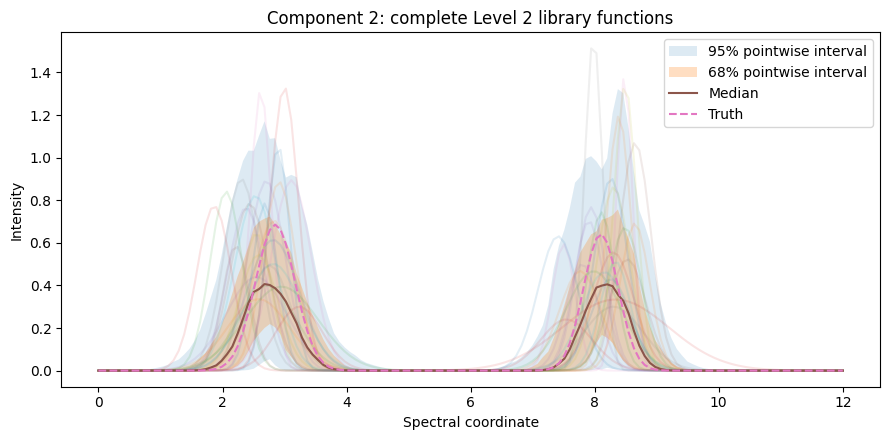

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))

for j in range(min(25, library.shape[0])):
    ax.plot(data.E, library[j], alpha=0.12)

q025, q16, q50, q84, q975 = np.quantile(
    library,
    [0.025, 0.16, 0.50, 0.84, 0.975],
    axis=0,
)

ax.fill_between(data.E, q025, q975, alpha=0.15, label="95% pointwise interval")
ax.fill_between(data.E, q16, q84, alpha=0.25, label="68% pointwise interval")
ax.plot(data.E, q50, label="Median")
ax.plot(data.E, data.S_true[component], "--", label="Truth")

ax.set_xlabel("Spectral coordinate")
ax.set_ylabel("Intensity")
ax.set_title(f"Component {component+1}: complete Level 2 library functions")
ax.legend()
fig.tight_layout();

## Compute physical-intensity covariance and correlation

For an ensemble $S^{(d)}(E)$, covariance is computed across complete spectral draws.

The diagonal of the covariance matrix is the pointwise variance. Off-diagonal entries quantify coordinated spectral changes.

Correlation rescales covariance by the pointwise standard deviations. Positive values mean two intensities tend to move together; negative values mean they tend to move in opposite directions.

In [13]:
covariance = np.cov(library, rowvar=False, ddof=1)

sd = np.sqrt(np.maximum(np.diag(covariance), 0.0))
denom = np.outer(sd, sd)

correlation = np.divide(
    covariance,
    denom,
    out=np.zeros_like(covariance),
    where=denom > 1e-15,
)

print("Covariance shape:", covariance.shape)
print("Maximum pointwise SD:", sd.max())
print("Correlation range:", correlation.min(), correlation.max())

Covariance shape: (140, 140)
Maximum pointwise SD: 0.3549246115942447
Correlation range: -0.5849135894163087 1.0000000000000002


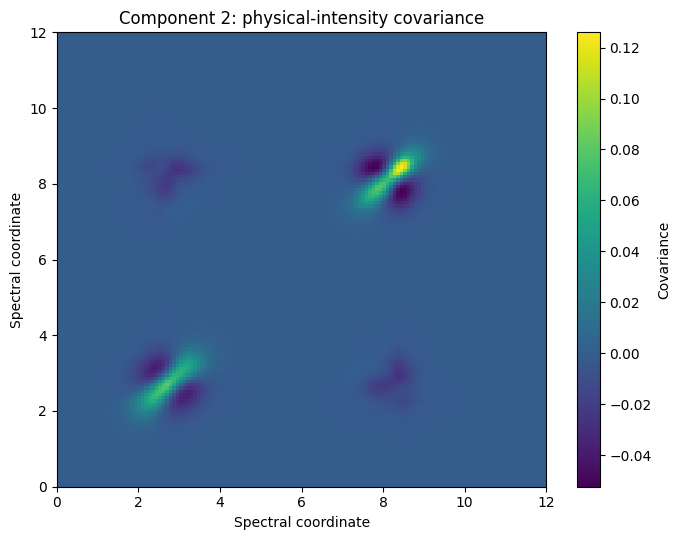

In [14]:
fig, ax = plt.subplots(figsize=(7, 5.5))

image = ax.imshow(
    covariance,
    origin="lower",
    aspect="auto",
    extent=[data.E[0], data.E[-1], data.E[0], data.E[-1]],
)

ax.set_xlabel("Spectral coordinate")
ax.set_ylabel("Spectral coordinate")
ax.set_title(f"Component {component+1}: physical-intensity covariance")
fig.colorbar(image, ax=ax, label="Covariance")
fig.tight_layout();

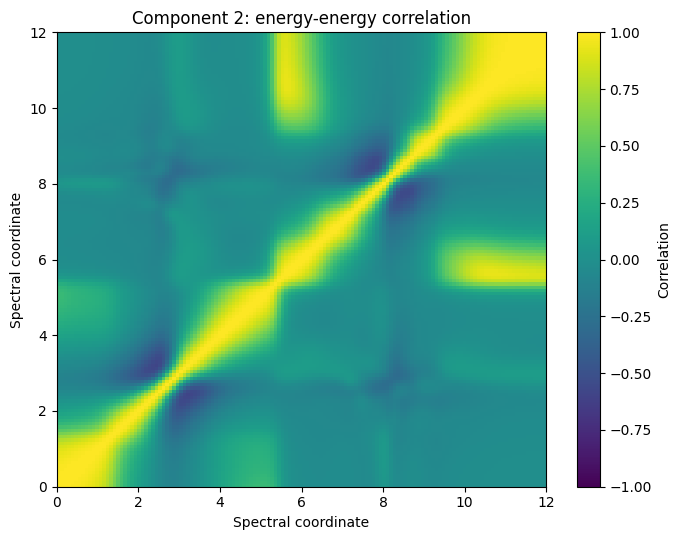

In [15]:
fig, ax = plt.subplots(figsize=(7, 5.5))

image = ax.imshow(
    correlation,
    origin="lower",
    aspect="auto",
    vmin=-1,
    vmax=1,
    extent=[data.E[0], data.E[-1], data.E[0], data.E[-1]],
)

ax.set_xlabel("Spectral coordinate")
ax.set_ylabel("Spectral coordinate")
ax.set_title(f"Component {component+1}: energy-energy correlation")
fig.colorbar(image, ax=ax, label="Correlation")
fig.tight_layout();

## Pointwise uncertainty and correlation answer different questions

Correlation can be large in weak spectral tails where the absolute variance is tiny. Plot the SD alongside the spectral mean before interpreting strong-looking correlation blocks.

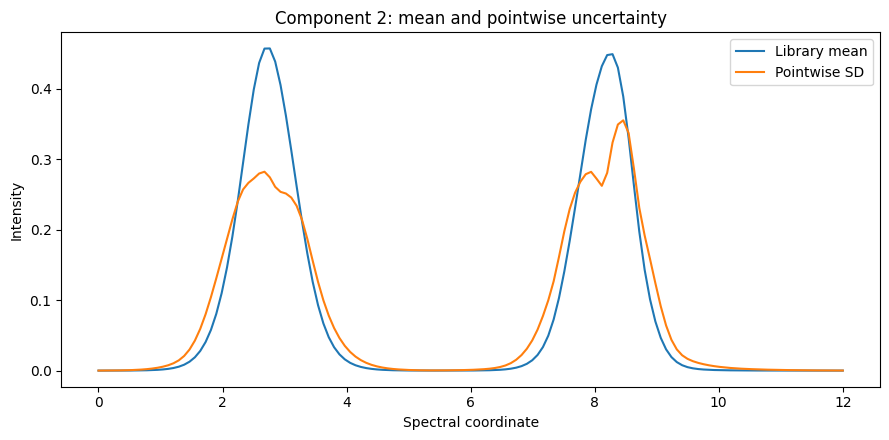

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(data.E, library.mean(axis=0), label="Library mean")
ax.plot(data.E, sd, label="Pointwise SD")

ax.set_xlabel("Spectral coordinate")
ax.set_ylabel("Intensity")
ax.set_title(f"Component {component+1}: mean and pointwise uncertainty")
ax.legend()
fig.tight_layout();

## Unit-area normalization imposes an exact covariance constraint

Every library spectrum is normalized to unit integrated area. Therefore fluctuations cannot change total area.

If $q$ contains trapezoidal integration weights and $K_S$ is the physical spectral covariance, the area constraint implies

$$K_S q \approx 0.$$

This is a useful numerical check and an example of how physical constraints appear directly in covariance structure.

In [17]:
E = data.E
dE = np.diff(E)

q = np.empty_like(E)
q[0] = 0.5 * dE[0]
q[-1] = 0.5 * dE[-1]
q[1:-1] = 0.5 * (dE[:-1] + dE[1:])

residual = covariance @ q

print("Maximum |K q|:", np.max(np.abs(residual)))
print("RMS |K q|:", np.sqrt(np.mean(residual**2)))

Maximum |K q|: 1.4751925809380895e-17
RMS |K q|: 2.786596762234533e-18


## Compare all four components

The same diagnostic can be summarized with one scalar per component, but the scalar should never replace the full covariance map.

In [18]:
u = pu.uncertainty_summary(data)

for k, value in enumerate(u["level2_relative_spectral_uncertainty"]):
    print(f"Component {k+1}: relative functional uncertainty = {value:.4f}")

Component 1: relative functional uncertainty = 0.2651
Component 2: relative functional uncertainty = 0.8206
Component 3: relative functional uncertainty = 0.3141
Component 4: relative functional uncertainty = 0.3029


## Takeaway

Level 2 uncertainty is inherently multivariate across spectral coordinate.

- Pointwise bands summarize marginal uncertainty.
- Covariance reveals absolute coordinated changes.
- Correlation highlights coupling patterns independent of scale.
- Unit-area normalization creates compensating correlations and a covariance null direction.

The next notebook shows where this structure comes from in the low-dimensional functional representation.